## Import das bibliotecas

In [119]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
from patsy import dmatrices
from sklearn.metrics import (mean_absolute_error, mean_squared_error, 
                             accuracy_score, f1_score, confusion_matrix, roc_auc_score)


## Carregamento dos datasets

In [120]:

# 1. Carregar os datasets
df_treino = pd.read_csv(r"C:\Users\erica\Documents\Mestrado\Projetos\Advanced_DS\Ames_Housing_Project\data\processed\treino.csv")
df_teste = pd.read_csv(r"C:\Users\erica\Documents\Mestrado\Projetos\Advanced_DS\Ames_Housing_Project\data\processed\teste_final.csv")
df_valid = pd.read_csv(r"C:\Users\erica\Documents\Mestrado\Projetos\Advanced_DS\Ames_Housing_Project\data\processed\validacao.csv")


### mapeamento price_tier

In [121]:
mapping = {'Baixo': 0, 'Médio': 1, 'Alto': 2}
df_treino['price_tier_code'] = df_treino['price_tier'].map(mapping)
df_valid['price_tier_code'] = df_valid['price_tier'].map(mapping)

### Baseline


In [122]:
# Baseline de Regressão
media_t = df_treino['SalePrice'].mean()
mae_b = mean_absolute_error(df_valid['SalePrice'], np.full(len(df_valid), media_t))
rmse_b = np.sqrt(mean_squared_error(df_valid['SalePrice'], np.full(len(df_valid), media_t)))

# Baseline de Classificação
classe_freq = df_treino['price_tier_code'].mode()[0]
acc_b = accuracy_score(df_valid['price_tier_code'], np.full(len(df_valid), classe_freq))
# F1 e ROC AUC baseline (usando probabilidades iguais para o AUC)
f1_b = f1_score(df_valid['price_tier_code'], np.full(len(df_valid), classe_freq), average='weighted')

In [123]:
def calcular_vif(formula, df):
    y, X = dmatrices(formula, df, return_type='dataframe')
    vif_df = pd.DataFrame()
    vif_df["feature"] = X.columns
    vif_df["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
    return vif_df[vif_df['feature'] != 'Intercept']

### Armazenamento de resultados


In [124]:
resultados_linear = {}
resultados_logistica = {}

## Modelos de regressão linear

### Formulas

In [125]:
F1 = 'SalePrice ~ Q("Gr Liv Area")'
F2 = 'SalePrice ~ Q("Gr Liv Area") + Q("Overall Qual")'
F3 = 'SalePrice ~ Q("Gr Liv Area") + qual_cond_interaction'
F4 = 'SalePrice ~ Q("Gr Liv Area") + house_age + Q("Total Bsmt SF")'
F5 = 'SalePrice ~ Q("Gr Liv Area") + Q("Overall Qual") + Q("Garage Cars") + total_bath'
F6 = 'SalePrice ~ Q("Gr Liv Area") + Q("Overall Qual") + Q("Fireplaces") + Q("Lot Area")'


### Modelo 1

In [126]:
nome = "L1"
formula = F1

modelo = smf.ols(formula, data=df_treino).fit()
print(modelo.summary()) # Aqui você verá o R-squared e Adj. R-squared

print("\n--- VIF ---")
print(calcular_vif(formula, df_treino))

preds = modelo.predict(df_valid)
mae = mean_absolute_error(df_valid['SalePrice'], preds)
rmse = np.sqrt(mean_squared_error(df_valid['SalePrice'], preds))

# Salvando R2 junto com as métricas
resultados_linear[nome] = {'R2': modelo.rsquared, 'MAE': mae, 'RMSE': rmse}
print(f"{nome} - R2: {modelo.rsquared:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.503
Model:                            OLS   Adj. R-squared:                  0.503
Method:                 Least Squares   F-statistic:                     2073.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:06:13   Log-Likelihood:                -25194.
No. Observations:                2047   AIC:                         5.039e+04
Df Residuals:                    2045   BIC:                         5.040e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept         1.483e+04   3776.720  

### Modelo 2

In [127]:
nome = "L2"
formula = F2

modelo = smf.ols(formula, data=df_treino).fit()
print(modelo.summary()) # Aqui você verá o R-squared e Adj. R-squared

print("\n--- VIF ---")
print(calcular_vif(formula, df_treino))

preds = modelo.predict(df_valid)
mae = mean_absolute_error(df_valid['SalePrice'], preds)
rmse = np.sqrt(mean_squared_error(df_valid['SalePrice'], preds))

# Salvando R2 junto com as métricas
resultados_linear[nome] = {'R2': modelo.rsquared, 'MAE': mae, 'RMSE': rmse}
print(f"{nome} - R2: {modelo.rsquared:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     2935.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:06:13   Log-Likelihood:                -24525.
No. Observations:                2047   AIC:                         4.906e+04
Df Residuals:                    2044   BIC:                         4.907e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1.052e+05   3880.44

### Modelo 3

In [128]:
nome = "L3"
formula = F3

modelo = smf.ols(formula, data=df_treino).fit()
print(modelo.summary()) # Aqui você verá o R-squared e Adj. R-squared

print("\n--- VIF ---")
print(calcular_vif(formula, df_treino))

preds = modelo.predict(df_valid)
mae = mean_absolute_error(df_valid['SalePrice'], preds)
rmse = np.sqrt(mean_squared_error(df_valid['SalePrice'], preds))

# Salvando R2 junto com as métricas
resultados_linear[nome] = {'R2': modelo.rsquared, 'MAE': mae, 'RMSE': rmse}
print(f"{nome} - R2: {modelo.rsquared:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.599
Model:                            OLS   Adj. R-squared:                  0.598
Method:                 Least Squares   F-statistic:                     1525.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:06:13   Log-Likelihood:                -24976.
No. Observations:                2047   AIC:                         4.996e+04
Df Residuals:                    2044   BIC:                         4.997e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept             -4.911e+

### Modelo 4

In [129]:
nome = "L4"
formula = F4

modelo = smf.ols(formula, data=df_treino).fit()
print(modelo.summary()) # Aqui você verá o R-squared e Adj. R-squared

print("\n--- VIF ---")
print(calcular_vif(formula, df_treino))

preds = modelo.predict(df_valid)
mae = mean_absolute_error(df_valid['SalePrice'], preds)
rmse = np.sqrt(mean_squared_error(df_valid['SalePrice'], preds))

# Salvando R2 junto com as métricas
resultados_linear[nome] = {'R2': modelo.rsquared, 'MAE': mae, 'RMSE': rmse}
print(f"{nome} - R2: {modelo.rsquared:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     1995.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:06:13   Log-Likelihood:                -24509.
No. Observations:                2047   AIC:                         4.903e+04
Df Residuals:                    2043   BIC:                         4.905e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept           3.226e+04   3705

### Modelo 5

In [130]:
nome = "L5"
formula = F5
modelo = smf.ols(formula, data=df_treino).fit()
print(modelo.summary()) # Aqui você verá o R-squared e Adj. R-squared

print("\n--- VIF ---")
print(calcular_vif(formula, df_treino))

preds = modelo.predict(df_valid)
mae = mean_absolute_error(df_valid['SalePrice'], preds)
rmse = np.sqrt(mean_squared_error(df_valid['SalePrice'], preds))

# Salvando R2 junto com as métricas
resultados_linear[nome] = {'R2': modelo.rsquared, 'MAE': mae, 'RMSE': rmse}
print(f"{nome} - R2: {modelo.rsquared:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.777
Model:                            OLS   Adj. R-squared:                  0.776
Method:                 Least Squares   F-statistic:                     1775.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:06:13   Log-Likelihood:                -24376.
No. Observations:                2047   AIC:                         4.876e+04
Df Residuals:                    2042   BIC:                         4.879e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept          -1.02e+05   3634.32

### Modelo 6

In [131]:
nome = "L6"
formula = F6
modelo = smf.ols(formula, data=df_treino).fit()
print(modelo.summary()) # Aqui você verá o R-squared e Adj. R-squared

print("\n--- VIF ---")
print(calcular_vif(formula, df_treino))

preds = modelo.predict(df_valid)
mae = mean_absolute_error(df_valid['SalePrice'], preds)
rmse = np.sqrt(mean_squared_error(df_valid['SalePrice'], preds))

# Salvando R2 junto com as métricas
resultados_linear[nome] = {'R2': modelo.rsquared, 'MAE': mae, 'RMSE': rmse}
print(f"{nome} - R2: {modelo.rsquared:.4f}, MAE: {mae:.2f}, RMSE: {rmse:.2f}")

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.764
Model:                            OLS   Adj. R-squared:                  0.764
Method:                 Least Squares   F-statistic:                     1657.
Date:                Sun, 19 Apr 2026   Prob (F-statistic):               0.00
Time:                        23:06:13   Log-Likelihood:                -24430.
No. Observations:                2047   AIC:                         4.887e+04
Df Residuals:                    2042   BIC:                         4.890e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept         -1.067e+05   3891.59

## Modelos de regressão logistica

In [132]:
M1 = 'price_tier_code ~ Q("Overall Qual")'
M2 = 'price_tier_code ~ Q("Overall Qual") + Q("Gr Liv Area")'
M3 = 'price_tier_code ~ Q("Overall Qual") + qual_cond_interaction'
M4 = 'price_tier_code ~ Q("Gr Liv Area") + total_bath + Q("Garage Cars")'
M5 = 'price_tier_code ~ Q("Overall Qual") + house_age + Q("Total Bsmt SF")'
M6 = 'price_tier_code ~ Q("Overall Qual") + Q("Lot Area") + Q("Foundation_PConc")'

### Modelo 1

                          MNLogit Regression Results                          
Dep. Variable:        price_tier_code   No. Observations:                 2047
Model:                        MNLogit   Df Residuals:                     2043
Method:                           MLE   Df Model:                            2
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.2332
Time:                        23:06:13   Log-Likelihood:                -1700.9
converged:                       True   LL-Null:                       -2218.1
Covariance Type:            nonrobust   LLR p-value:                2.323e-225
price_tier_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.7168      0.330    -11.256      0.000      -4.364      -3.070
Q("Overall Qual")     0.7423      0.060     12.328      0.000       0.624       0.860
------------------------

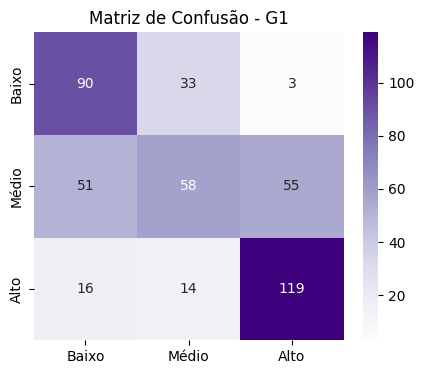

In [133]:
nome = "G1"
formula = M1

# 1. Fit e Summary
modelo = smf.mnlogit(formula, data=df_treino).fit(disp=0)
print(modelo.summary())

# 2. Predições (Classes e Probabilidades)
probabilidades = modelo.predict(df_valid) # Retorna matriz [n_samples, 3]
preds = probabilidades.idxmax(axis=1)

# 3. Cálculo de Métricas
acc = accuracy_score(df_valid['price_tier_code'], preds)
f1 = f1_score(df_valid['price_tier_code'], preds, average='weighted')

# ROC AUC Multinomial (One-vs-Rest)
# Precisamos das probabilidades e dos labels reais
roc_auc = roc_auc_score(df_valid['price_tier_code'], probabilidades, 
                        multi_class='ovr', average='weighted')

resultados_logistica[nome] = {'Acurácia': acc, 'F1-Score': f1, 'ROC_AUC': roc_auc}

print(f"\n--- MÉTRICAS {nome} ---")
print(f"Acurácia: {acc:.4f} | F1-Score: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

# 4. Matriz de Confusão
plt.figure(figsize=(5,4))
cm = confusion_matrix(df_valid['price_tier_code'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão - {nome}')
plt.show()

### Modelo 2

                          MNLogit Regression Results                          
Dep. Variable:        price_tier_code   No. Observations:                 2047
Model:                        MNLogit   Df Residuals:                     2041
Method:                           MLE   Df Model:                            4
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.2348
Time:                        23:06:38   Log-Likelihood:                -1697.3
converged:                       True   LL-Null:                       -2218.1
Covariance Type:            nonrobust   LLR p-value:                3.214e-224
price_tier_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -3.7879      0.334    -11.326      0.000      -4.443      -3.132
Q("Overall Qual")     0.7030      0.066     10.724      0.000       0.574       0.831
Q("Gr Liv Area")      0.

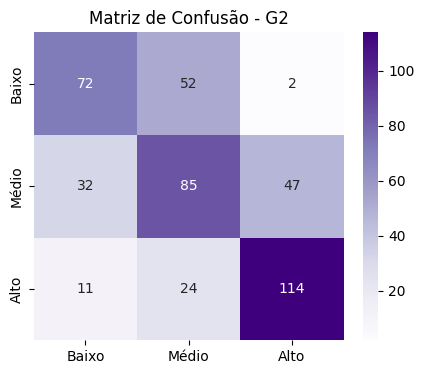

In [140]:
nome = "G2"
formula = M2

# 1. Fit e Summary
modelo = smf.mnlogit(formula, data=df_treino).fit(disp=0)
print(modelo.summary())

# 2. Predições (Classes e Probabilidades)
probabilidades = modelo.predict(df_valid) # Retorna matriz [n_samples, 3]
preds = probabilidades.idxmax(axis=1)

# 3. Cálculo de Métricas
acc = accuracy_score(df_valid['price_tier_code'], preds)
f1 = f1_score(df_valid['price_tier_code'], preds, average='weighted')

# ROC AUC Multinomial (One-vs-Rest)
# Precisamos das probabilidades e dos labels reais
roc_auc = roc_auc_score(df_valid['price_tier_code'], probabilidades, 
                        multi_class='ovr', average='weighted')

resultados_logistica[nome] = {'Acurácia': acc, 'F1-Score': f1, 'ROC_AUC': roc_auc}

print(f"\n--- MÉTRICAS {nome} ---")
print(f"Acurácia: {acc:.4f} | F1-Score: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

# 4. Matriz de Confusão
plt.figure(figsize=(5,4))
cm = confusion_matrix(df_valid['price_tier_code'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão - {nome}')
plt.show()

### Modelo 3

                          MNLogit Regression Results                          
Dep. Variable:        price_tier_code   No. Observations:                 2047
Model:                        MNLogit   Df Residuals:                     2041
Method:                           MLE   Df Model:                            4
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.2631
Time:                        23:06:45   Log-Likelihood:                -1634.5
converged:                       True   LL-Null:                       -2218.1
Covariance Type:            nonrobust   LLR p-value:                2.060e-251
    price_tier_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -3.9462      0.338    -11.669      0.000      -4.609      -3.283
Q("Overall Qual")         1.1013      0.087     12.650      0.000       0.931       1.272
qual_con

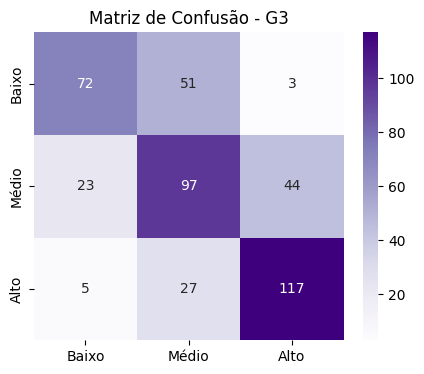

In [141]:
nome = "G3"
formula = M3

# 1. Fit e Summary
modelo = smf.mnlogit(formula, data=df_treino).fit(disp=0)
print(modelo.summary())

# 2. Predições (Classes e Probabilidades)
probabilidades = modelo.predict(df_valid) # Retorna matriz [n_samples, 3]
preds = probabilidades.idxmax(axis=1)

# 3. Cálculo de Métricas
acc = accuracy_score(df_valid['price_tier_code'], preds)
f1 = f1_score(df_valid['price_tier_code'], preds, average='weighted')

# ROC AUC Multinomial (One-vs-Rest)
# Precisamos das probabilidades e dos labels reais
roc_auc = roc_auc_score(df_valid['price_tier_code'], probabilidades, 
                        multi_class='ovr', average='weighted')

resultados_logistica[nome] = {'Acurácia': acc, 'F1-Score': f1, 'ROC_AUC': roc_auc}

print(f"\n--- MÉTRICAS {nome} ---")
print(f"Acurácia: {acc:.4f} | F1-Score: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

# 4. Matriz de Confusão
plt.figure(figsize=(5,4))
cm = confusion_matrix(df_valid['price_tier_code'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão - {nome}')
plt.show()

### Modelo 4

                          MNLogit Regression Results                          
Dep. Variable:        price_tier_code   No. Observations:                 2047
Model:                        MNLogit   Df Residuals:                     2039
Method:                           MLE   Df Model:                            6
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.1927
Time:                        23:06:55   Log-Likelihood:                -1790.7
converged:                       True   LL-Null:                       -2218.1
Covariance Type:            nonrobust   LLR p-value:                2.109e-181
price_tier_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            -2.2837      0.218    -10.495      0.000      -2.710      -1.857
Q("Gr Liv Area")     -0.0002      0.000     -1.513      0.130      -0.001    7.08e-05
total_bath            0.

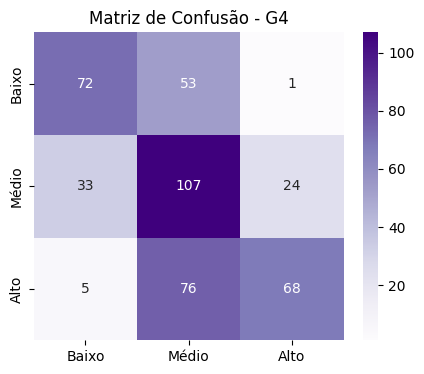

In [142]:
nome = 'G4'
formula = M4

# 1. Fit e Summary
modelo = smf.mnlogit(formula, data=df_treino).fit(disp=0)
print(modelo.summary())

# 2. Predições (Classes e Probabilidades)
probabilidades = modelo.predict(df_valid) # Retorna matriz [n_samples, 3]
preds = probabilidades.idxmax(axis=1)

# 3. Cálculo de Métricas
acc = accuracy_score(df_valid['price_tier_code'], preds)
f1 = f1_score(df_valid['price_tier_code'], preds, average='weighted')

# ROC AUC Multinomial (One-vs-Rest)
# Precisamos das probabilidades e dos labels reais
roc_auc = roc_auc_score(df_valid['price_tier_code'], probabilidades, 
                        multi_class='ovr', average='weighted')

resultados_logistica[nome] = {'Acurácia': acc, 'F1-Score': f1, 'ROC_AUC': roc_auc}

print(f"\n--- MÉTRICAS {nome} ---")
print(f"Acurácia: {acc:.4f} | F1-Score: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

# 4. Matriz de Confusão
plt.figure(figsize=(5,4))
cm = confusion_matrix(df_valid['price_tier_code'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão - {nome}')
plt.show()

### Modelo 5

                          MNLogit Regression Results                          
Dep. Variable:        price_tier_code   No. Observations:                 2047
Model:                        MNLogit   Df Residuals:                     2039
Method:                           MLE   Df Model:                            6
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.3873
Time:                        23:07:02   Log-Likelihood:                -1358.9
converged:                       True   LL-Null:                       -2218.1
Covariance Type:            nonrobust   LLR p-value:                     0.000
 price_tier_code=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -1.5873      0.440     -3.605      0.000      -2.450      -0.724
Q("Overall Qual")      0.5151      0.070      7.328      0.000       0.377       0.653
house_age           

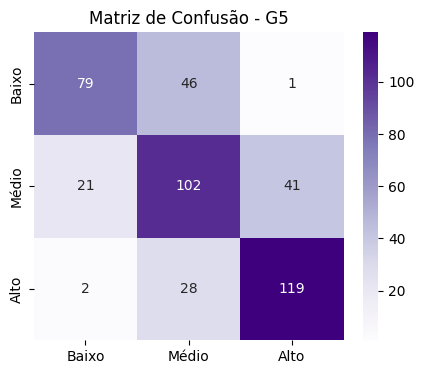

In [143]:
nome = 'G5'
formula = M5

# 1. Fit e Summary
modelo = smf.mnlogit(formula, data=df_treino).fit(disp=0)
print(modelo.summary())

# 2. Predições (Classes e Probabilidades)
probabilidades = modelo.predict(df_valid) # Retorna matriz [n_samples, 3]
preds = probabilidades.idxmax(axis=1)

# 3. Cálculo de Métricas
acc = accuracy_score(df_valid['price_tier_code'], preds)
f1 = f1_score(df_valid['price_tier_code'], preds, average='weighted')

# ROC AUC Multinomial (One-vs-Rest)
# Precisamos das probabilidades e dos labels reais
roc_auc = roc_auc_score(df_valid['price_tier_code'], probabilidades, 
                        multi_class='ovr', average='weighted')

resultados_logistica[nome] = {'Acurácia': acc, 'F1-Score': f1, 'ROC_AUC': roc_auc}

print(f"\n--- MÉTRICAS {nome} ---")
print(f"Acurácia: {acc:.4f} | F1-Score: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

# 4. Matriz de Confusão
plt.figure(figsize=(5,4))
cm = confusion_matrix(df_valid['price_tier_code'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão - {nome}')
plt.show()

### Modelo 6

                          MNLogit Regression Results                          
Dep. Variable:        price_tier_code   No. Observations:                 2047
Model:                        MNLogit   Df Residuals:                     2039
Method:                           MLE   Df Model:                            6
Date:                Sun, 19 Apr 2026   Pseudo R-squ.:                  0.2947
Time:                        23:07:08   Log-Likelihood:                -1564.4
converged:                       True   LL-Null:                       -2218.1
Covariance Type:            nonrobust   LLR p-value:                2.637e-279
    price_tier_code=1       coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                -4.8411      0.389    -12.442      0.000      -5.604      -4.078
Q("Overall Qual")         0.6763      0.064     10.537      0.000       0.551       0.802
Q("Lot A

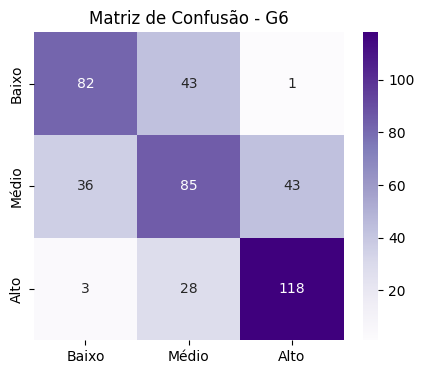

In [144]:
nome = "G6"
formula = M6

# 1. Fit e Summary
modelo = smf.mnlogit(formula, data=df_treino).fit(disp=0)
print(modelo.summary())

# 2. Predições (Classes e Probabilidades)
probabilidades = modelo.predict(df_valid) # Retorna matriz [n_samples, 3]
preds = probabilidades.idxmax(axis=1)

# 3. Cálculo de Métricas
acc = accuracy_score(df_valid['price_tier_code'], preds)
f1 = f1_score(df_valid['price_tier_code'], preds, average='weighted')

# ROC AUC Multinomial (One-vs-Rest)
# Precisamos das probabilidades e dos labels reais
roc_auc = roc_auc_score(df_valid['price_tier_code'], probabilidades, 
                        multi_class='ovr', average='weighted')

resultados_logistica[nome] = {'Acurácia': acc, 'F1-Score': f1, 'ROC_AUC': roc_auc}

print(f"\n--- MÉTRICAS {nome} ---")
print(f"Acurácia: {acc:.4f} | F1-Score: {f1:.4f} | ROC AUC: {roc_auc:.4f}")

# 4. Matriz de Confusão
plt.figure(figsize=(5,4))
cm = confusion_matrix(df_valid['price_tier_code'], preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title(f'Matriz de Confusão - {nome}')
plt.show()

## Performance

In [145]:
print("=== RANKING REGRESSÃO LINEAR ===")
df_l = pd.DataFrame(resultados_linear).T
df_l.loc['BASELINE'] = {'R2': 0, 'MAE': mae_b, 'RMSE': rmse_b}
print(df_l.sort_values('RMSE'))

print("\n=== RANKING REGRESSÃO LOGÍSTICA ===")
df_g = pd.DataFrame(resultados_logistica).T
df_g.loc['BASELINE'] = {'Acurácia': acc_b, 'F1-Score': f1_b, 'ROC_AUC': 0.5}
print(df_g.sort_values('ROC_AUC', ascending=False))

=== RANKING REGRESSÃO LINEAR ===
                R2           MAE          RMSE
L6        0.764469  26141.757837  37413.098426
L5        0.776643  26237.747822  37579.520843
L4        0.745515  26333.263126  38103.845502
L2        0.741736  27635.972219  38982.537316
L3        0.598719  34811.310630  49758.206683
L1        0.503346  38675.765738  56247.189667
BASELINE  0.000000  61320.993605  83016.410654

=== RANKING REGRESSÃO LOGÍSTICA ===
          Acurácia  F1-Score   ROC_AUC
G5        0.683371  0.683620  0.837881
G6        0.649203  0.646589  0.826272
G3        0.651481  0.650407  0.808318
G2        0.617312  0.614933  0.788381
G1        0.608200  0.591439  0.779858
G4        0.562642  0.565733  0.758701
BASELINE  0.373576  0.203206  0.500000


## Teste dos melhores modelos

             RESULTADOS FINAIS (TESTE FINAL)              
REGRESSÃO (L6):
  -> RMSE Final: 43882.48
  -> MAE Final:  28628.46
------------------------------
CLASSIFICAÇÃO (G5):
  -> Acurácia Final: 0.6955
  -> F1-Score Final: 0.6929
  -> ROC AUC Final:  0.8465


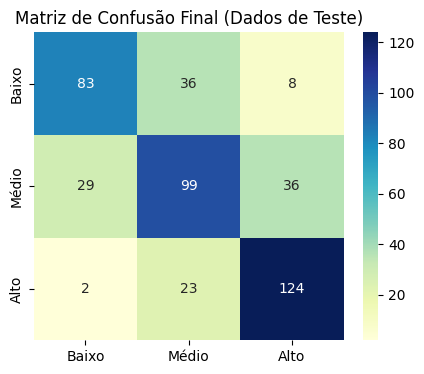

In [146]:
# 2. Preparar os dados de teste (Mapeamento)
df_teste['price_tier_code'] = df_teste['price_tier'].map(mapping)

# --- VEREDITO: REGRESSÃO LINEAR (L6) ---
formula_l6 = F6
modelo_l6_final = smf.ols(formula_l6, data=df_treino).fit()

preds_l6 = modelo_l6_final.predict(df_teste)
rmse_final = np.sqrt(mean_squared_error(df_teste['SalePrice'], preds_l6))
mae_final = mean_absolute_error(df_teste['SalePrice'], preds_l6)

# --- VEREDITO: REGRESSÃO LOGÍSTICA (G5) ---
# Substitua pela sua fórmula exata do G5:
formula_g5 = M5
modelo_g5_final = smf.mnlogit(formula_g5, data=df_treino).fit(disp=0)

prob_g5 = modelo_g5_final.predict(df_teste)
preds_g5 = prob_g5.idxmax(axis=1)

acc_final = accuracy_score(df_teste['price_tier_code'], preds_g5)
f1_final = f1_score(df_teste['price_tier_code'], preds_g5, average='weighted')
roc_auc_final = roc_auc_score(df_teste['price_tier_code'], prob_g5, multi_class='ovr', average='weighted')

# --- APRESENTAÇÃO DOS RESULTADOS FINAIS ---
print("==========================================================")
print("             RESULTADOS FINAIS (TESTE FINAL)              ")
print("==========================================================")
print(f"REGRESSÃO (L6):")
print(f"  -> RMSE Final: {rmse_final:.2f}")
print(f"  -> MAE Final:  {mae_final:.2f}")
print("-" * 30)
print(f"CLASSIFICAÇÃO (G5):")
print(f"  -> Acurácia Final: {acc_final:.4f}")
print(f"  -> F1-Score Final: {f1_final:.4f}")
print(f"  -> ROC AUC Final:  {roc_auc_final:.4f}")
print("==========================================================")

# Matriz de Confusão Final
plt.figure(figsize=(5,4))
cm_final = confusion_matrix(df_teste['price_tier_code'], preds_g5)
sns.heatmap(cm_final, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['Baixo', 'Médio', 'Alto'], yticklabels=['Baixo', 'Médio', 'Alto'])
plt.title('Matriz de Confusão Final (Dados de Teste)')
plt.show()